<a href="https://colab.research.google.com/github/ekyaaa/pengolahan-citra/blob/main/Week10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Tugas Praktikum
Week 10

# Preparation

In [19]:
import cv2
import numpy as np
from numpy.lib.stride_tricks import as_strided
import matplotlib.pyplot as plt
from skimage import filters, io, color, morphology
from skimage.util import img_as_float
from skimage.morphology import skeletonize
from IPython.display import display

# Practicum

## 1. Image Dilation from Scratch

In [20]:
def image_dilation(
    F: np.ndarray,
    w: int
) -> np.ndarray:
    """
    Perform image dilation on a grayscale image using a square structuring element.

    Parameters
    ----------
    F : np.ndarray
        Input grayscale image as a 2D NumPy array.
    w : int
        Size of the square structuring element (must be odd).

    Returns
    -------
    np.ndarray
        Dilated image as a 2D NumPy array with the same shape as the input.
    """
    p, q = F.shape
    img_d = np.zeros((p, q), dtype=np.uint8)

    # Generate structuring element (square matrix of ones)
    SED = np.ones((w, w), dtype=np.uint8)
    constant1 = (w - 1) // 2

    for i in range(constant1, p - constant1):
        for j in range(constant1, q - constant1):
            temp = F[
                i - constant1:i + constant1 + 1,
                j - constant1:j + constant1 + 1
            ]
            product = temp * SED
            img_d[i, j] = np.max(product)

    return img_d

In [21]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


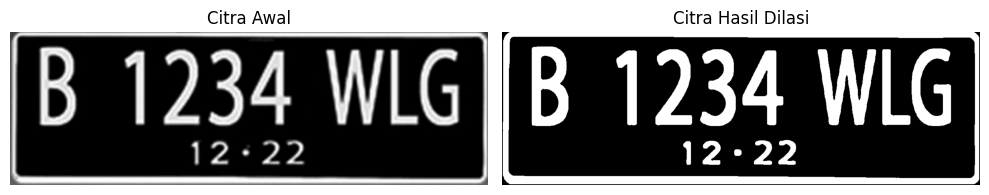

In [22]:
img = cv2.imread('/content/drive/MyDrive/pcvk_images/plat_nomor.png', flags=cv2.IMREAD_GRAYSCALE)

if img is None:
    raise Exception('Image is not found!')

ret, thresh = cv2.threshold(
    img,
    thresh=125,
    maxval=200,
    type=cv2.THRESH_BINARY
)

img_d = image_dilation(thresh, w=5)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))  # 1 row, 2 columns

# First image
axes[0].imshow(img, cmap='gray')
axes[0].set_title('Citra Awal')
axes[0].axis('off')

# Second image
axes[1].imshow(img_d, cmap='gray')
axes[1].set_title('Citra Hasil Dilasi')
axes[1].axis('off')

plt.tight_layout()
plt.show()

## 2. Image Dilation with OpenCV

Kernel: 
 [[1 1 1]
 [1 1 1]
 [1 1 1]]


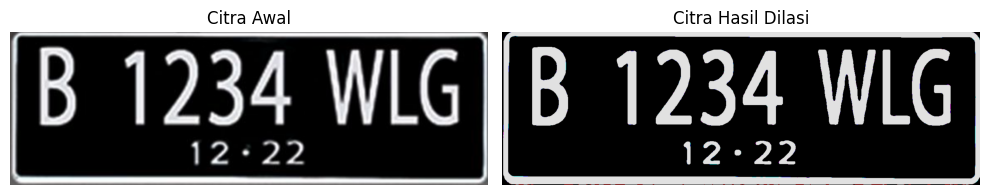

In [23]:
img = cv2.imread('/content/drive/MyDrive/pcvk_images/plat_nomor.png')

if img is None:
    raise Exception('Image is not found!')

ret, thresh = cv2.threshold(
    img,
    thresh=127,
    maxval=225,
    type=cv2.THRESH_BINARY
)
kernel = np.ones((3,3),np.uint16)
img_d = cv2.dilate(thresh,kernel, iterations = 1)
print('Kernel: \n', kernel)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))  # 1 row, 2 columns

# First image
axes[0].imshow(img)
axes[0].set_title('Citra Awal')
axes[0].axis('off')

# Second image
axes[1].imshow(img_d, cmap='gray')
axes[1].set_title('Citra Hasil Dilasi')
axes[1].axis('off')

plt.tight_layout()
plt.show()

## 3. Image Erotion from Scratch

In [24]:
def image_erosion(
    F: np.ndarray,
    k: int
) -> np.ndarray:
    """
    Perform image erosion on a grayscale or binary image using a square structuring element.

    Parameters
    ----------
    F : np.ndarray
        Input image as a 2D NumPy array (uint8).
    k : int
        Size of the square structuring element (must be odd).

    Returns
    -------
    np.ndarray
        Eroded image as a 2D NumPy array.
    """
    m, n = F.shape

    # Generate structuring element (square matrix of ones)
    SE = np.ones((k, k), dtype=np.uint8)
    constant = (k - 1) // 2

    # Initialize output image
    img_e = np.zeros((m, n), dtype=np.uint8)

    # Erosion process
    for i in range(constant, m - constant):
        for j in range(constant, n - constant):
            temp = F[
                i - constant:i + constant + 1,
                j - constant:j + constant + 1
            ]
            product = temp * SE
            img_e[i, j] = np.min(product)

    return img_e

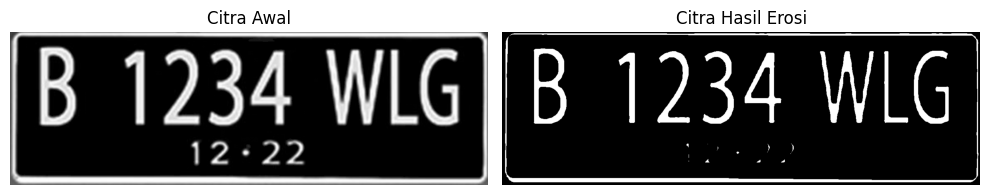

In [25]:
img = cv2.imread('/content/drive/MyDrive/pcvk_images/plat_nomor.png', flags=cv2.IMREAD_GRAYSCALE)

if img is None:
    raise Exception('Image is not found!')


ret1, thresh1 = cv2.threshold(
    img,
    thresh=175,
    maxval=225,
    type=cv2.THRESH_BINARY
)

img_e = image_erosion(thresh1, k=5)


fig, axes = plt.subplots(1, 2, figsize=(10, 4))  # 1 row, 2 columns

# First image
axes[0].imshow(img, cmap='gray')
axes[0].set_title('Citra Awal')
axes[0].axis('off')

# Second image
axes[1].imshow(img_e, cmap='gray')
axes[1].set_title('Citra Hasil Erosi')
axes[1].axis('off')

plt.tight_layout()
plt.show()

## 4. Image Erotion with OpenCV

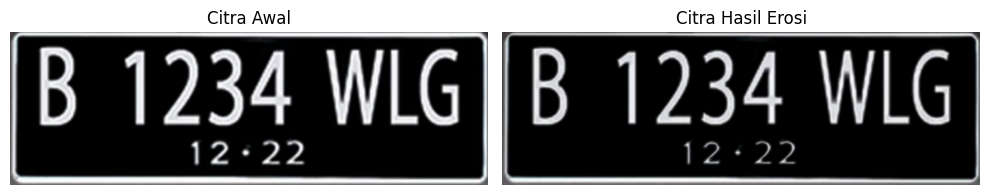

In [26]:
img = cv2.imread('/content/drive/MyDrive/pcvk_images/plat_nomor.png')

if img is None:
    raise Exception('Image is not found!')

kernel = np.ones((5,5),np.uint8)
img_e = cv2.erode(img,kernel,iterations = 1)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))  # 1 row, 2 columns

# First image
axes[0].imshow(img)
axes[0].set_title('Citra Awal')
axes[0].axis('off')

# Second image
axes[1].imshow(img_e, cmap='gray')
axes[1].set_title('Citra Hasil Erosi')
axes[1].axis('off')

plt.tight_layout()
plt.show()

## 5. Image Opening from Scratch

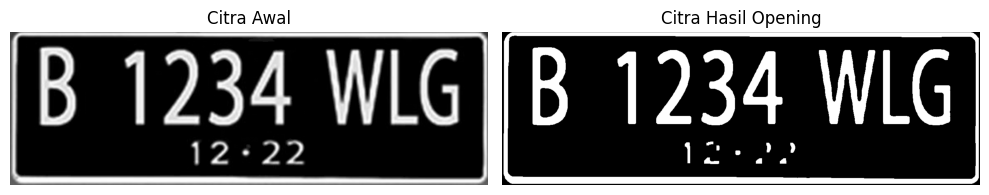

In [27]:
img = cv2.imread('/content/drive/MyDrive/pcvk_images/plat_nomor.png', flags=cv2.IMREAD_GRAYSCALE)

if img is None:
    raise Exception('Image is not found!')

reto, thresh = cv2.threshold(
    img,
    thresh=127,
    maxval=225,
    type=cv2.THRESH_BINARY
)

img_o = image_dilation(image_erosion(thresh, k=7), w=7)


fig, axes = plt.subplots(1, 2, figsize=(10, 4))  # 1 row, 2 columns

# First image
axes[0].imshow(img, cmap='gray')
axes[0].set_title('Citra Awal')
axes[0].axis('off')

# Second image
axes[1].imshow(img_o, cmap='gray')
axes[1].set_title('Citra Hasil Opening')
axes[1].axis('off')

plt.tight_layout()
plt.show()

## 6. Image Opening with OpenCV

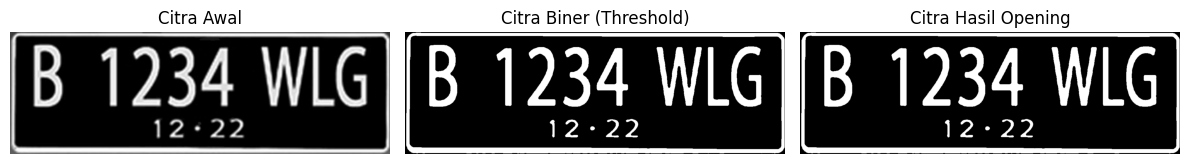

In [28]:
img = cv2.imread('/content/drive/MyDrive/pcvk_images/plat_nomor.png', flags=cv2.IMREAD_GRAYSCALE)

if img is None:
    raise Exception('Image is not found!')

ret, thresh = cv2.threshold(
    img,
    thresh=127,
    maxval=225,
    type=cv2.THRESH_BINARY
)

kernel = np.ones((3,3),np.uint8)
img_o = cv2.morphologyEx(thresh,cv2.MORPH_OPEN, kernel)

images = [img, thresh, img_o]
titles = ['Citra Awal', 'Citra Biner (Threshold)', 'Citra Hasil Opening']

# Create subplots: 1 row, 3 columns
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

# Loop through each subplot
for ax, image, title in zip(axes, images, titles):
    ax.imshow(image, cmap='gray')
    ax.set_title(title)
    ax.axis('off')

plt.tight_layout()
plt.show()

## 7. Image Closing from Scratch

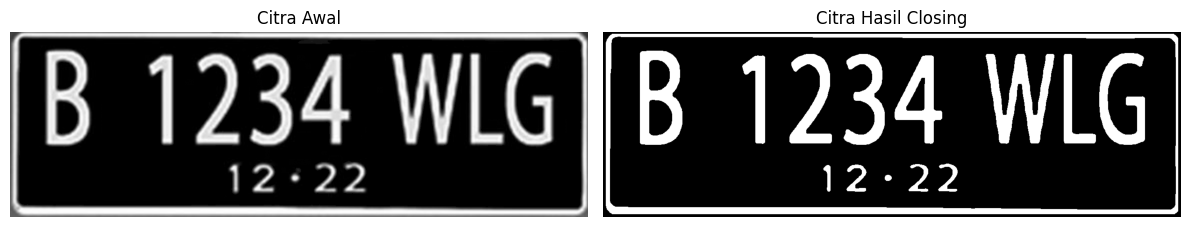

In [29]:
img = cv2.imread('/content/drive/MyDrive/pcvk_images/plat_nomor.png', flags=cv2.IMREAD_GRAYSCALE)

if img is None:
    raise Exception('Image is not found!')

retc, thresh = cv2.threshold(
    img,
    thresh=127,
    maxval=225,
    type=cv2.THRESH_BINARY
)

img_c = image_erosion(image_dilation(thresh, w=7), k=7)

images = [img, img_c]
titles = ['Citra Awal', 'Citra Hasil Closing']

# Create subplots: 1 row, 3 columns
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Loop through each subplot
for ax, image, title in zip(axes, images, titles):
    ax.imshow(image, cmap='gray')
    ax.set_title(title)
    ax.axis('off')

plt.tight_layout()
plt.show()

## 8. Image Closing with OpenCV

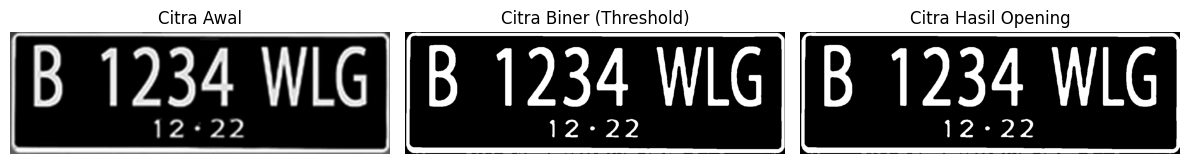

In [30]:
img = cv2.imread('/content/drive/MyDrive/pcvk_images/plat_nomor.png', flags=cv2.IMREAD_GRAYSCALE)

if img is None:
    raise Exception('Image is not found!')

ret, thresh = cv2.threshold(
    img,
    thresh=127,
    maxval=225,
    type=cv2.THRESH_BINARY
)
kernel = np.ones((3,3),np.uint8)
img_c = cv2.morphologyEx(thresh,cv2.MORPH_CLOSE, kernel)

images = [img, thresh, img_c]
titles = ['Citra Awal', 'Citra Biner (Threshold)', 'Citra Hasil Opening']

# Create subplots: 1 row, 3 columns
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

# Loop through each subplot
for ax, image, title in zip(axes, images, titles):
    ax.imshow(image, cmap='gray')
    ax.set_title(title)
    ax.axis('off')

plt.tight_layout()
plt.show()

## 9. Advanced Dilation

In [31]:
def image_dilation_optimized(
    F: np.ndarray,
    SE: np.ndarray
) -> np.ndarray:
    """
    Perform image dilation on a grayscale image using a custom or square structuring element.

    Parameters
    ----------
    F : np.ndarray
        Input grayscale image as a 2D NumPy array.
    SE : np.ndarray
        Custom structuring element (2D NumPy array of 0s and 1s).

    Returns
    -------
    np.ndarray
        Dilated image as a 2D NumPy array with the same shape as the input.
    """
    if SE.ndim != 2:
        raise ValueError("Structuring element must be a 2D array.")
    if SE.shape[0] % 2 == 0 or SE.shape[1] % 2 == 0:
        raise ValueError("Structuring element dimensions must be odd.")

    # Generate structuring element
    SE = SE.astype(np.uint8)

    p, q = F.shape
    img_d = np.zeros((p, q), dtype=np.uint8)

    # Padding to handle borders
    se_h, se_w = SE.shape
    pad_h, pad_w = se_h // 2, se_w // 2
    F_padded = np.pad(
        F,
        pad_width=((pad_h, pad_h), (pad_w, pad_w)),
        mode='constant',
        constant_values=0
    )

    # Create sliding window view of the image
    shape = (F.shape[0], F.shape[1], se_h, se_w)
    strides = F_padded.strides * 2
    windows = as_strided(F_padded, shape=shape, strides=strides)

    # Apply dilation operation
    # Each window corresponds to a neighborhood of one output pixel.
    # Multiply with SE and take the max.
    dilated = np.max(windows * SE, axis=(2, 3))

    return dilated.astype(np.uint8)

### 9.1 Cross (3x3) and (5x5)

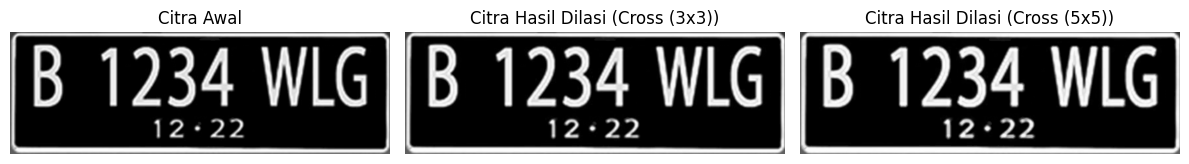

In [32]:
cross_SE_3 = np.array([
    [0, 1, 0],
    [1, 1, 1],
    [0, 1, 0]
], dtype = np.uint8)

cross_SE_5 = np.array([
    [0, 0, 1, 0, 0],
    [0, 0, 1, 0, 0],
    [1, 1, 1, 1, 1],
    [0, 0, 1, 0, 0],
    [0, 0, 1, 0, 0]
], dtype = np.uint8)



img = cv2.imread('/content/drive/MyDrive/pcvk_images/plat_nomor.png', flags=cv2.IMREAD_GRAYSCALE)

if img is None:
    raise Exception('Image is not found!')

ret, thresh = cv2.threshold(
    img,
    thresh=127,
    maxval=255,
    type=cv2.THRESH_BINARY
)

img_d_c3 = image_dilation_optimized(img, SE=cross_SE_3)
img_d_c5 = image_dilation_optimized(img, SE=cross_SE_5)

images = [img, img_d_c3, img_d_c5]
titles = ['Citra Awal', 'Citra Hasil Dilasi (Cross (3x3))', 'Citra Hasil Dilasi (Cross (5x5))']

# Result visualization
# Create subplots: 1 row, 3 columns
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

# Loop through each subplot
for ax, image, title in zip(axes, images, titles):
    ax.imshow(image, cmap='gray')
    ax.set_title(title)
    ax.axis('off')

plt.tight_layout()
plt.show()

### 9.2 Circular (3x3) and (5x5)

Circular SE (3x3): 


array([[0, 1, 0],
       [1, 1, 1],
       [0, 1, 0]], dtype=uint8)

Circular_SE (5x5): 


array([[0, 0, 1, 0, 0],
       [1, 1, 1, 1, 1],
       [1, 1, 1, 1, 1],
       [1, 1, 1, 1, 1],
       [0, 0, 1, 0, 0]], dtype=uint8)

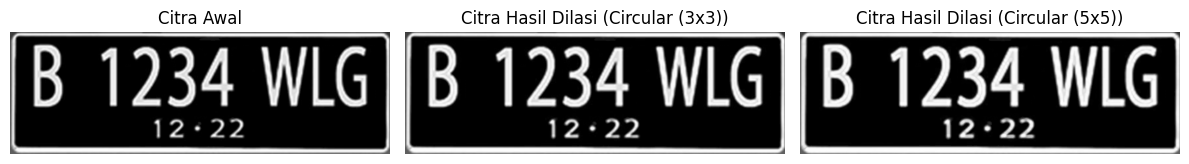

In [33]:
circular_SE_3 = cv2.getStructuringElement(shape=cv2.MORPH_ELLIPSE, ksize=(3, 3))
circular_SE_5 = cv2.getStructuringElement(shape=cv2.MORPH_ELLIPSE, ksize=(5, 5))

print('Circular SE (3x3): ')
display(circular_SE_3)

print('Circular_SE (5x5): ')
display(circular_SE_5)


img = cv2.imread('/content/drive/MyDrive/pcvk_images/plat_nomor.png', flags=cv2.IMREAD_GRAYSCALE)

if img is None:
    raise Exception('Image is not found!')

ret, thresh = cv2.threshold(
    img,
    thresh=127,
    maxval=255,
    type=cv2.THRESH_BINARY
)

img_d_o3 = image_dilation_optimized(img, SE=circular_SE_3)
img_d_o5 = image_dilation_optimized(img, SE=circular_SE_5)

images = [img, img_d_o3, img_d_o5]
titles = ['Citra Awal', 'Citra Hasil Dilasi (Circular (3x3))', 'Citra Hasil Dilasi (Circular (5x5))']

# Result visualization
# Create subplots: 1 row, 3 columns
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

# Loop through each subplot
for ax, image, title in zip(axes, images, titles):
    ax.imshow(image, cmap='gray')
    ax.set_title(title)
    ax.axis('off')

plt.tight_layout()
plt.show()

### 9.3 Rectangle (3x5) and (5x7)

Rectangle SE (3x5): 


array([[0, 0, 1, 0, 0],
       [1, 1, 1, 1, 1],
       [0, 0, 1, 0, 0]], dtype=uint8)

Rectangle SE (5x7): 


array([[0, 0, 0, 1, 0, 0, 0],
       [1, 1, 1, 1, 1, 1, 1],
       [1, 1, 1, 1, 1, 1, 1],
       [1, 1, 1, 1, 1, 1, 1],
       [0, 0, 0, 1, 0, 0, 0]], dtype=uint8)

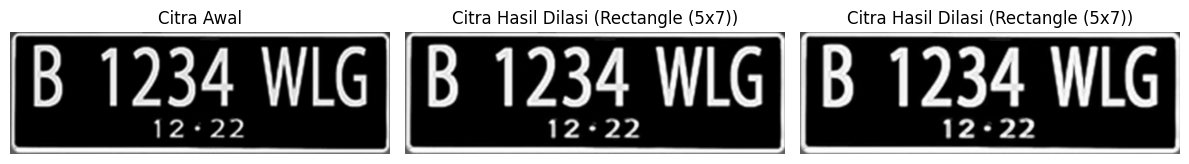

In [34]:
rectangle_SE_3x5 = cv2.getStructuringElement(shape=cv2.MORPH_ELLIPSE, ksize=(5, 3))
rectangle_SE_5x7 = cv2.getStructuringElement(shape=cv2.MORPH_ELLIPSE, ksize=(7, 5))

print('Rectangle SE (3x5): ')
display(rectangle_SE_3x5)

print('Rectangle SE (5x7): ')
display(rectangle_SE_5x7)

img = cv2.imread('/content/drive/MyDrive/pcvk_images/plat_nomor.png', flags=cv2.IMREAD_GRAYSCALE)

if img is None:
    raise Exception('Image is not found!')

ret, thresh = cv2.threshold(
    img,
    thresh=127,
    maxval=255,
    type=cv2.THRESH_BINARY
)

img_d_r35 = image_dilation_optimized(img, SE=rectangle_SE_3x5)
img_d_r57 = image_dilation_optimized(img, SE=rectangle_SE_5x7)

images = [img, img_d_r35, img_d_r57]
titles = ['Citra Awal', 'Citra Hasil Dilasi (Rectangle (5x7))', 'Citra Hasil Dilasi (Rectangle (5x7))']

# Result visualization
# Create subplots: 1 row, 3 columns
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

# Loop through each subplot
for ax, image, title in zip(axes, images, titles):
    ax.imshow(image, cmap='gray')
    ax.set_title(title)
    ax.axis('off')

plt.tight_layout()
plt.show()


### 9.4 Line vertical 3 and 5

Line vertical SE (3): 


array([[1],
       [1],
       [1]], dtype=uint8)

Line vertical SE (5): 


array([[1],
       [1],
       [1],
       [1],
       [1]], dtype=uint8)

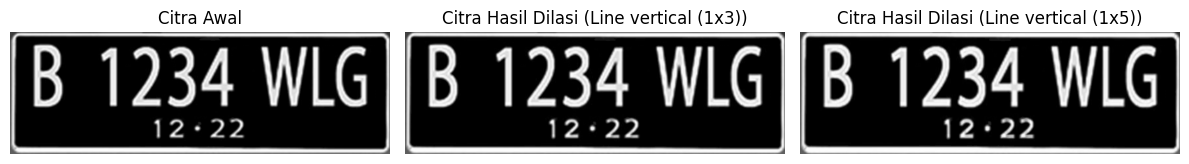

In [35]:
l_vertical_SE_3 = cv2.getStructuringElement(shape=cv2.MORPH_ELLIPSE, ksize=(1, 3))
l_vertical_SE_5 = cv2.getStructuringElement(shape=cv2.MORPH_ELLIPSE, ksize=(1, 5))

print('Line vertical SE (3): ')
display(l_vertical_SE_3)

print('Line vertical SE (5): ')
display(l_vertical_SE_5)

img = cv2.imread('/content/drive/MyDrive/pcvk_images/plat_nomor.png', flags=cv2.IMREAD_GRAYSCALE)

if img is None:
    raise Exception('Image is not found!')

ret, thresh = cv2.threshold(
    img,
    thresh=127,
    maxval=255,
    type=cv2.THRESH_BINARY
)

img_d_lv3 = image_dilation_optimized(img, SE=l_vertical_SE_3)
img_d_lv5 = image_dilation_optimized(img, SE=l_vertical_SE_5)

images = [img, img_d_lv3, img_d_lv5]
titles = ['Citra Awal', 'Citra Hasil Dilasi (Line vertical (1x3))', 'Citra Hasil Dilasi (Line vertical (1x5))']

# Result visualization
# Create subplots: 1 row, 3 columns
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

# Loop through each subplot
for ax, image, title in zip(axes, images, titles):
    ax.imshow(image, cmap='gray')
    ax.set_title(title)
    ax.axis('off')

plt.tight_layout()
plt.show()

## 10. Tophat

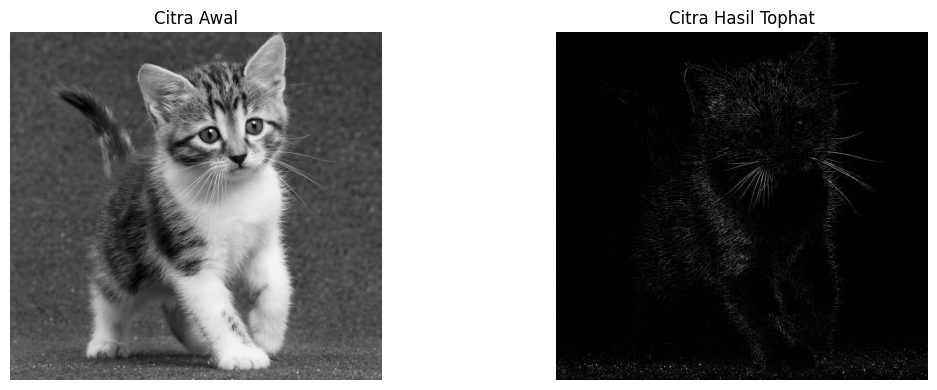

In [36]:
img = cv2.imread('/content/drive/MyDrive/pcvk_images/Images/kitten01.jpg')

if img is None:
    raise Exception('Image is not found!')

img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Applying the Top-Hat operation
tophat_img = cv2.morphologyEx(
    img,
    op=cv2.MORPH_TOPHAT,
    kernel=cv2.getStructuringElement(shape=cv2.MORPH_RECT, ksize=(3, 3))
)

images = [img, tophat_img]
titles = ['Citra Awal', 'Citra Hasil Tophat']

# Result visualization
# Create subplots: 1 row, 2 columns
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Loop through each subplot
for ax, image, title in zip(axes, images, titles):
    ax.imshow(image, cmap='gray')
    ax.set_title(title)
    ax.axis('off')

plt.tight_layout()
plt.show()

## 11. Blackhat

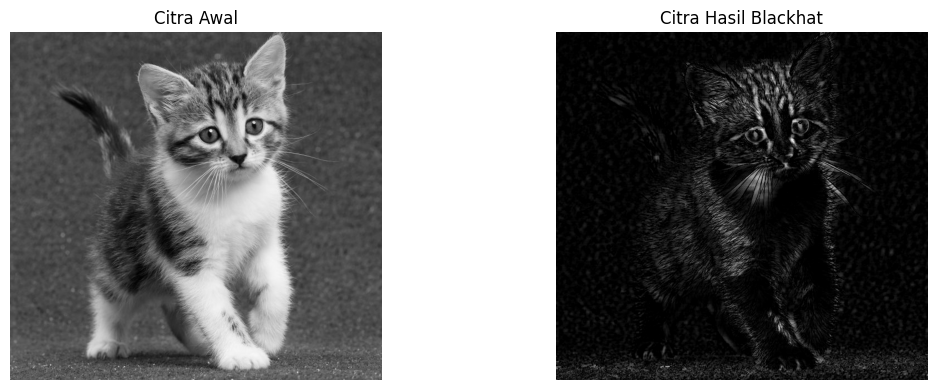

In [37]:
img = cv2.imread('/content/drive/MyDrive/pcvk_images/Images/kitten01.jpg')

if img is None:
    raise Exception('Image is not found!')

img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Applying the Top-Hat operation
blackhat_img = cv2.morphologyEx(
    img,
    op=cv2.MORPH_BLACKHAT,
    kernel=cv2.getStructuringElement(shape=cv2.MORPH_RECT, ksize=(13, 5))
)

images = [img, blackhat_img]
titles = ['Citra Awal', 'Citra Hasil Blackhat']

# Result visualization
# Create subplots: 1 row, 2 columns
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Loop through each subplot
for ax, image, title in zip(axes, images, titles):
    ax.imshow(image, cmap='gray')
    ax.set_title(title)
    ax.axis('off')

plt.tight_layout()
plt.show()

## 12. Skeleton

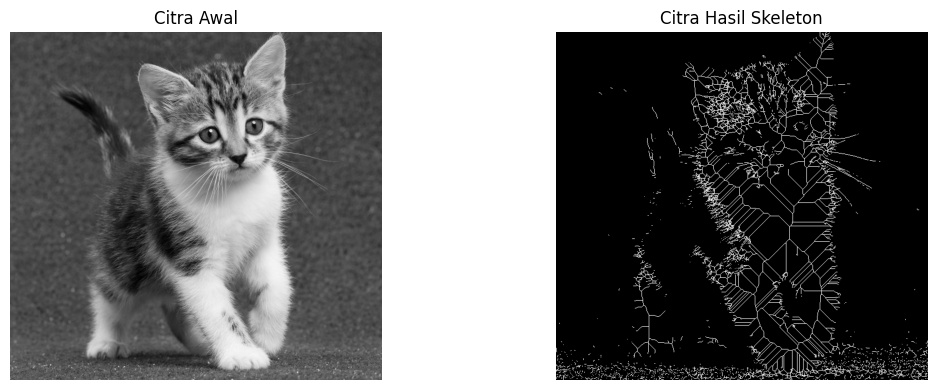

In [38]:
img = cv2.imread('/content/drive/MyDrive/pcvk_images/Images/kitten01.jpg', flags=cv2.IMREAD_GRAYSCALE)

if img is None:
    raise Exception('Image is not found!')

binary = img > filters.threshold_triangle(img)

# true false to one
binary_cp = binary.copy()
binary_cp[binary_cp == True] = 1
binary_cp[binary_cp == False] = 0

# skeletonize image
skeleton_img = skeletonize(binary_cp)


# Result visualization
images = [img, skeleton_img]
titles = ['Citra Awal', 'Citra Hasil Skeleton']

# Create subplots: 1 row, 2 columns
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Loop through each subplot
for ax, image, title in zip(axes, images, titles):
    ax.imshow(image, cmap='gray')
    ax.set_title(title)
    ax.axis('off')

plt.tight_layout()
plt.show()

## 13. Skeleton Inverse

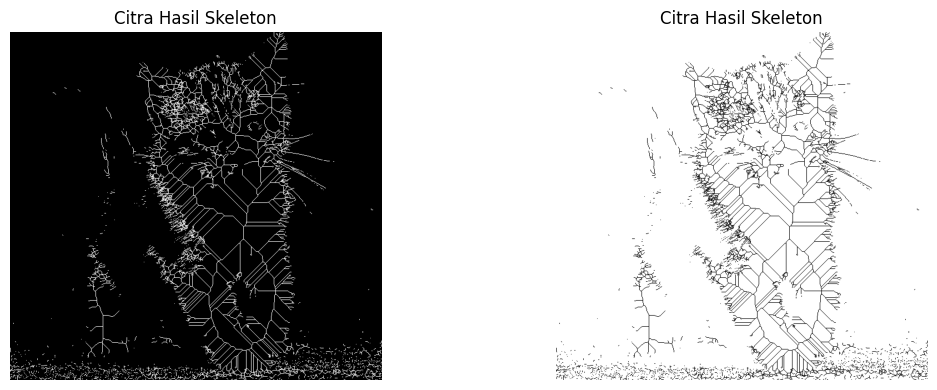

In [39]:
img = cv2.imread('/content/drive/MyDrive/pcvk_images/Images/kitten01.jpg', flags=cv2.IMREAD_GRAYSCALE)

if img is None:
    raise Exception('Image is not found!')

# Note: we want the black bits to be True, so use <
binary = img < filters.threshold_triangle(img)

# skeletonize image
skeleton_inv_img = skeletonize(binary)


# Result visualization
img_objects = [
    {
        'img': img,
        'title': 'Citra awal',
        'cmap': 'gray'
    },
    {
        'img': img,
        'title': 'Citra Hasil Skeleton Inverse',
        'cmap': 'gray_r'
    }
]
images = [img, skeleton_inv_img]
titles = ['Citra Awal', 'Citra Hasil Skeleton Inverse']

# Create subplots: 1 row, 2 columns
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Loop through each subplot
for ax, img in zip(axes, img_objects):
    ax.imshow(image, cmap=img['cmap'])
    ax.set_title(title)
    ax.axis('off')

plt.tight_layout()
plt.show()

## 14. Thickening

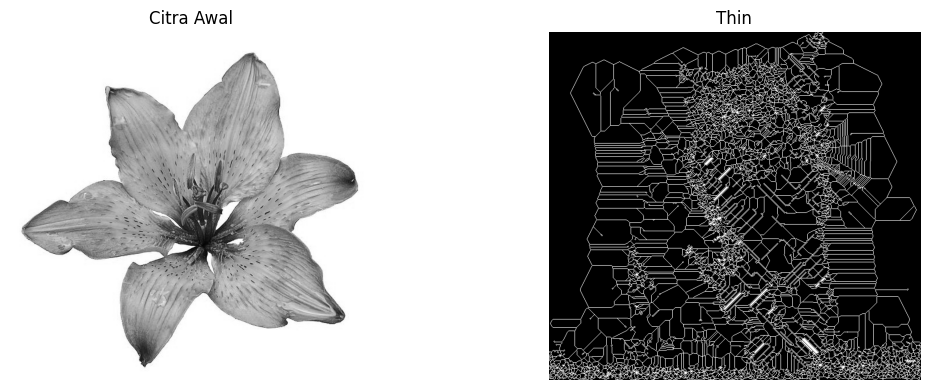

In [40]:
img = img_as_float(color.rgb2gray(io.imread('/content/drive/MyDrive/pcvk_images/Images/lily.jpg')))

image_binary = image < 0.5

out_skeletonize = morphology.skeletonize(image_binary)
out_thin = morphology.thin(image_binary)


# Result visualization
images = [img, out_thin]
titles = ['Citra Awal', 'Thin']

# Create subplots: 1 row, 2 columns
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Loop through each subplot
for ax, image, title in zip(axes, images, titles):
    ax.imshow(image, cmap='gray')
    ax.set_title(title)
    ax.axis('off')

plt.tight_layout()
plt.show()